In [1]:
import csv
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NLP_Ctrl-Alt-Elite/data/cleaned_dataset.csv')
df.rename(columns={'cleaned_lemmatized': 'lemmatized'}, inplace=True)

In [4]:
df['word_count'] = df['lemmatized'].apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())
print("95th percentile:", df['word_count'].quantile(0.95))

count    41863.000000
mean       124.545900
std        271.954314
min          1.000000
25%         17.000000
50%         46.000000
75%        147.000000
max      25444.000000
Name: word_count, dtype: float64
95th percentile: 493.0


In [5]:
print(df.groupby('label')['word_count'].describe())

# also peek at the extreme outliers
print(df[df['word_count'] > 1000]['label'].value_counts())

         count        mean         std  min   25%   50%    75%      max
label                                                                  
0      20956.0   83.398931  179.702401  1.0  10.0  20.0   77.0   6999.0
1      20907.0  165.789305  335.154171  1.0  34.0  97.0  202.0  25444.0
label
1    156
0    109
Name: count, dtype: int64


In [6]:
MAX_VOCAB = 15000
MAX_LEN = 250   # adjust based on the percentile check above

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['lemmatized'])

sequences = tokenizer.texts_to_sequences(df['lemmatized'])
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

X = padded
y = df['label'].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# Compute weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.9988070384730092), 1: np.float64(1.0011958146487294)}


In [9]:
EMBED_DIM = 128

model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=MAX_VOCAB,
        output_dim=EMBED_DIM
    ),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid', dtype='float32')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 250, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971,521 (7.52 MB)

 Trainable params: 1,971,521 (7.52 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7135 - loss: 0.5557 - val_accuracy: 0.7799 - val_loss: 0.4747
Epoch 2/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8268 - loss: 0.4467 - val_accuracy: 0.7793 - val_loss: 0.5090
Epoch 3/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.8492 - loss: 0.3835 - val_accuracy: 0.9546 - val_loss: 0.1508
Epoch 4/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9743 - loss: 0.0991 - val_accuracy: 0.9821 - val_loss: 0.0597
Epoch 5/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9897 - loss: 0.0422 - val_accuracy: 0.9881 - val_loss: 0.0481
Epoch 6/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9944 - loss: 0.0244 - val_accuracy: 0.9866 - val_loss: 0.0595
Epoch 7/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9970 - loss: 0.0151 - val_accuracy: 0.9866 - val_loss: 0.0601
Epoch 8/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9978 - loss: 0.0118 - 

262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Optimal threshold: 0.362  (default was 0.5)

               precision    recall  f1-score   support

         ham       0.99      0.98      0.99      4191
        spam       0.98      0.99      0.99      4182

    accuracy                           0.99      8373
   macro avg       0.99      0.99      0.99      8373
weighted avg       0.99      0.99      0.99      8373

ROC-AUC: 0.9979948093093294


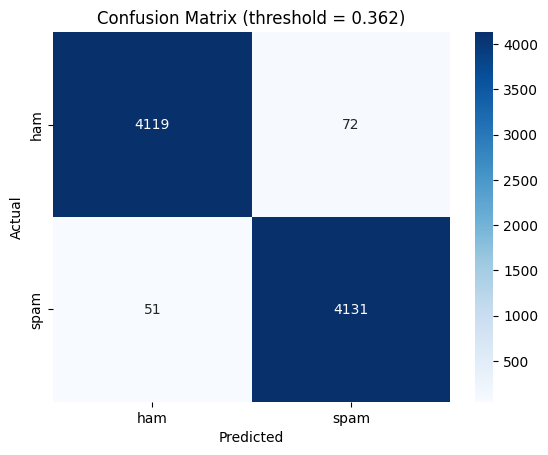

In [11]:
# 1. Get probabilities
y_pred_prob = model.predict(X_test)

# 2. Find optimal threshold via Precision-Recall curve
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {best_threshold:.3f}  (default was 0.5)")

# 3. Apply optimal threshold instead of 0.5
y_pred = (y_pred_prob > best_threshold).astype(int).flatten()

# 4. Classification report
print("\n", classification_report(y_test, y_pred, target_names=['ham', 'spam']))

# 5. ROC-AUC (always uses probabilities, not affected by threshold)
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold = {best_threshold:.3f})')
SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/NLP_Ctrl-Alt-Elite/DL_model"
plt.savefig(f"{SAVE_DIR}/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

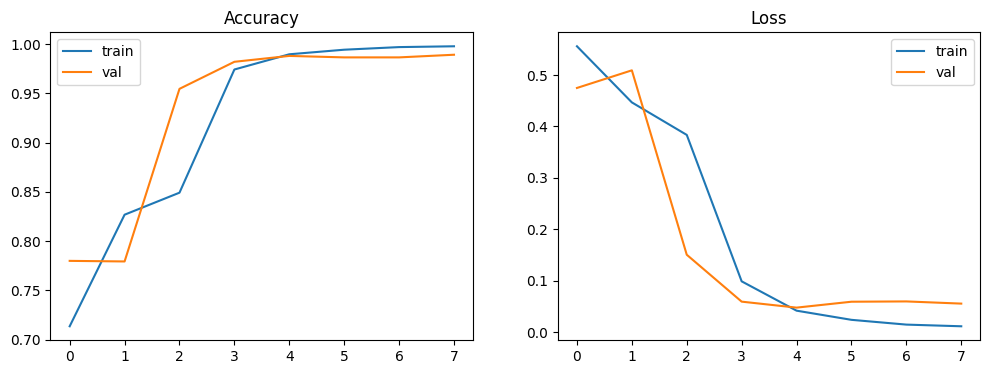

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()

plt.savefig(f"{SAVE_DIR}/training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
import pickle

# Save model
model.save(f"{SAVE_DIR}/spam_lstm_model.keras")

# Save tokenizer
with open(f"{SAVE_DIR}/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save threshold
np.save(f"{SAVE_DIR}/best_threshold.npy", best_threshold)